In [ ]:
pip install scikit-learn xgboost

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
file_path = 'month_data.xlsx'
df = pd.read_excel(file_path)

df.columns = [col.strip().replace('\n', ' ').replace('\\', '').replace('ْ', '').replace('  ', ' ') for col in df.columns]

# Sorting months
df['Month'] = pd.Categorical(df['Month'], categories=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
], ordered=True)

df = df.sort_values('Month')

# Adding energy in millions for scaling
# df['Energy (Millions)'] = df['Enegry Consumptoin'] / 1_000_000

In [3]:
df.dropna(inplace=True)

In [6]:
df.describe()

,Year,Inflow ar ROFeed (MG),Outflow at ROProduct (MG),ROF Temp F,ROF EC µS/cm,ROF pH,ROF Turbidity NTU,ROF TOC ppm,ROP EC µS/cm,ROP pH,ROP TurbidityNTU,ROP CO2 ppm,ROP TOC ppm,Enegry Consumptoin
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,6.000000e+01
mean,2022.000000,3236.980317,2745.029717,79.322650,1841.151317,6.900483,0.033233,8.101200,38.209100,5.312017,0.021300,116.032000,0.053533,5.293641e+06
std,1.426148,556.315522,470.284657,3.625039,278.406527,0.003744,0.022583,0.617086,10.980709,0.187841,0.016459,60.118641,0.008709,1.049081e+06
min,2020.000000,1243.939000,1056.814000,73.230000,1604.000000,6.900000,0.020000,6.580000,23.600000,4.900000,0.010000,49.630000,0.040000,1.765336e+06
25%,2021.000000,3079.285500,2615.317000,76.192500,1672.000000,6.900000,0.020000,7.657500,30.350000,5.100000,0.010000,66.497500,0.050000,4.833676e+06
50%,2022.000000,3283.789500,2784.005000,79.365000,1709.500000,6.900000,0.030000,8.305000,35.850000,5.400000,0.020000,92.000000,0.050000,5.260066e+06
75%,2023.000000,3397.086000,2879.664750,82.917500,1858.750000,6.900000,0.030000,8.532500,43.475000,5.500000,0.020000,151.830000,0.060000,5.884192e+06
max,2024.000000,4289.286000,3647.004000,85.580000,2603.560000,6.929000,0.120000,9.210000,73.846000,5.600000,0.098000,325.000000,0.082000,7.468672e+06


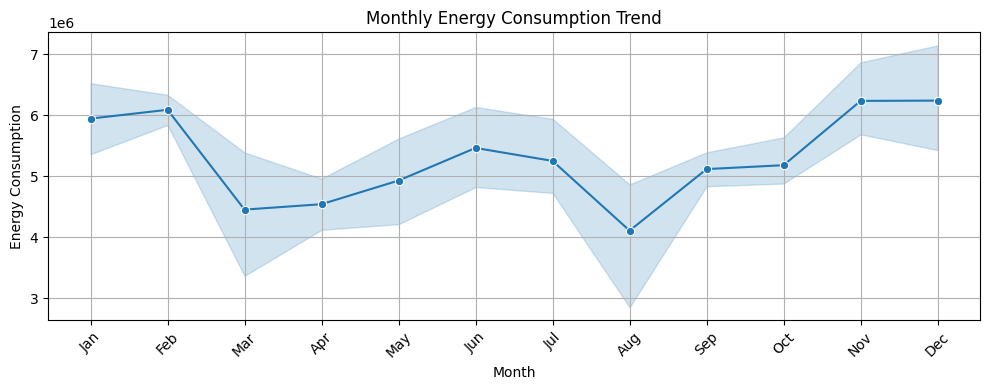

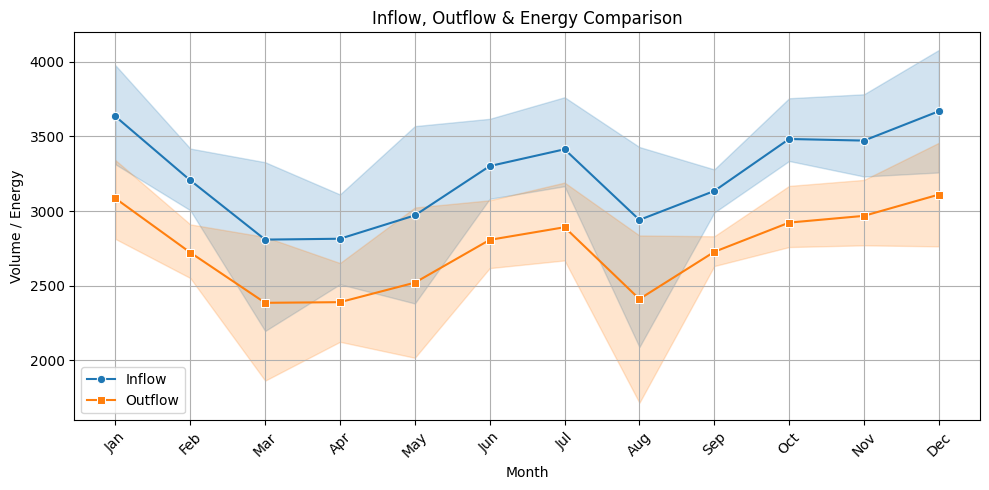

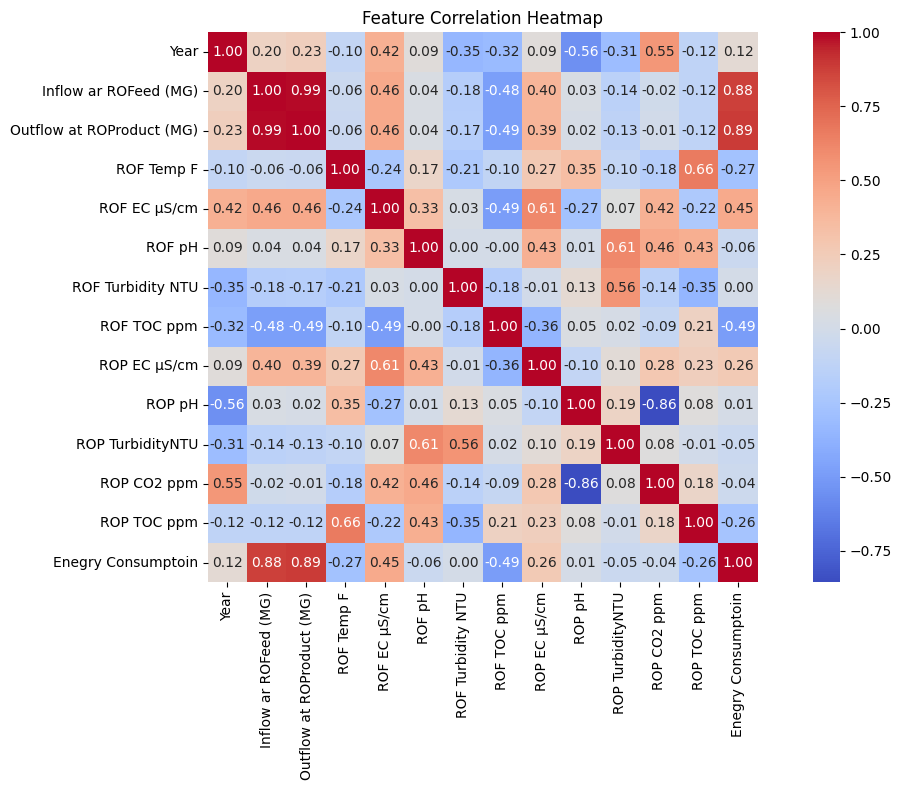

In [5]:

# ---- 1. Energy Consumption Trend ----
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Month', y='Enegry Consumptoin', marker='o')
plt.title('Monthly Energy Consumption Trend')
plt.ylabel('Energy Consumption')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- 2. Inflow, Outflow vs Energy ----
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Month', y='Inflow ar ROFeed (MG)', label='Inflow', marker='o')
sns.lineplot(data=df, x='Month', y='Outflow at ROProduct (MG)', label='Outflow', marker='s')
# sns.lineplot(data=df, x='Month', y='Energy (Millions)', label='Energy (Millions)', marker='^')
plt.title('Inflow, Outflow & Energy Comparison')
plt.ylabel('Volume / Energy')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---- 3. Correlation Heatmap ----
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


<Figure size 1400x1000 with 0 Axes>

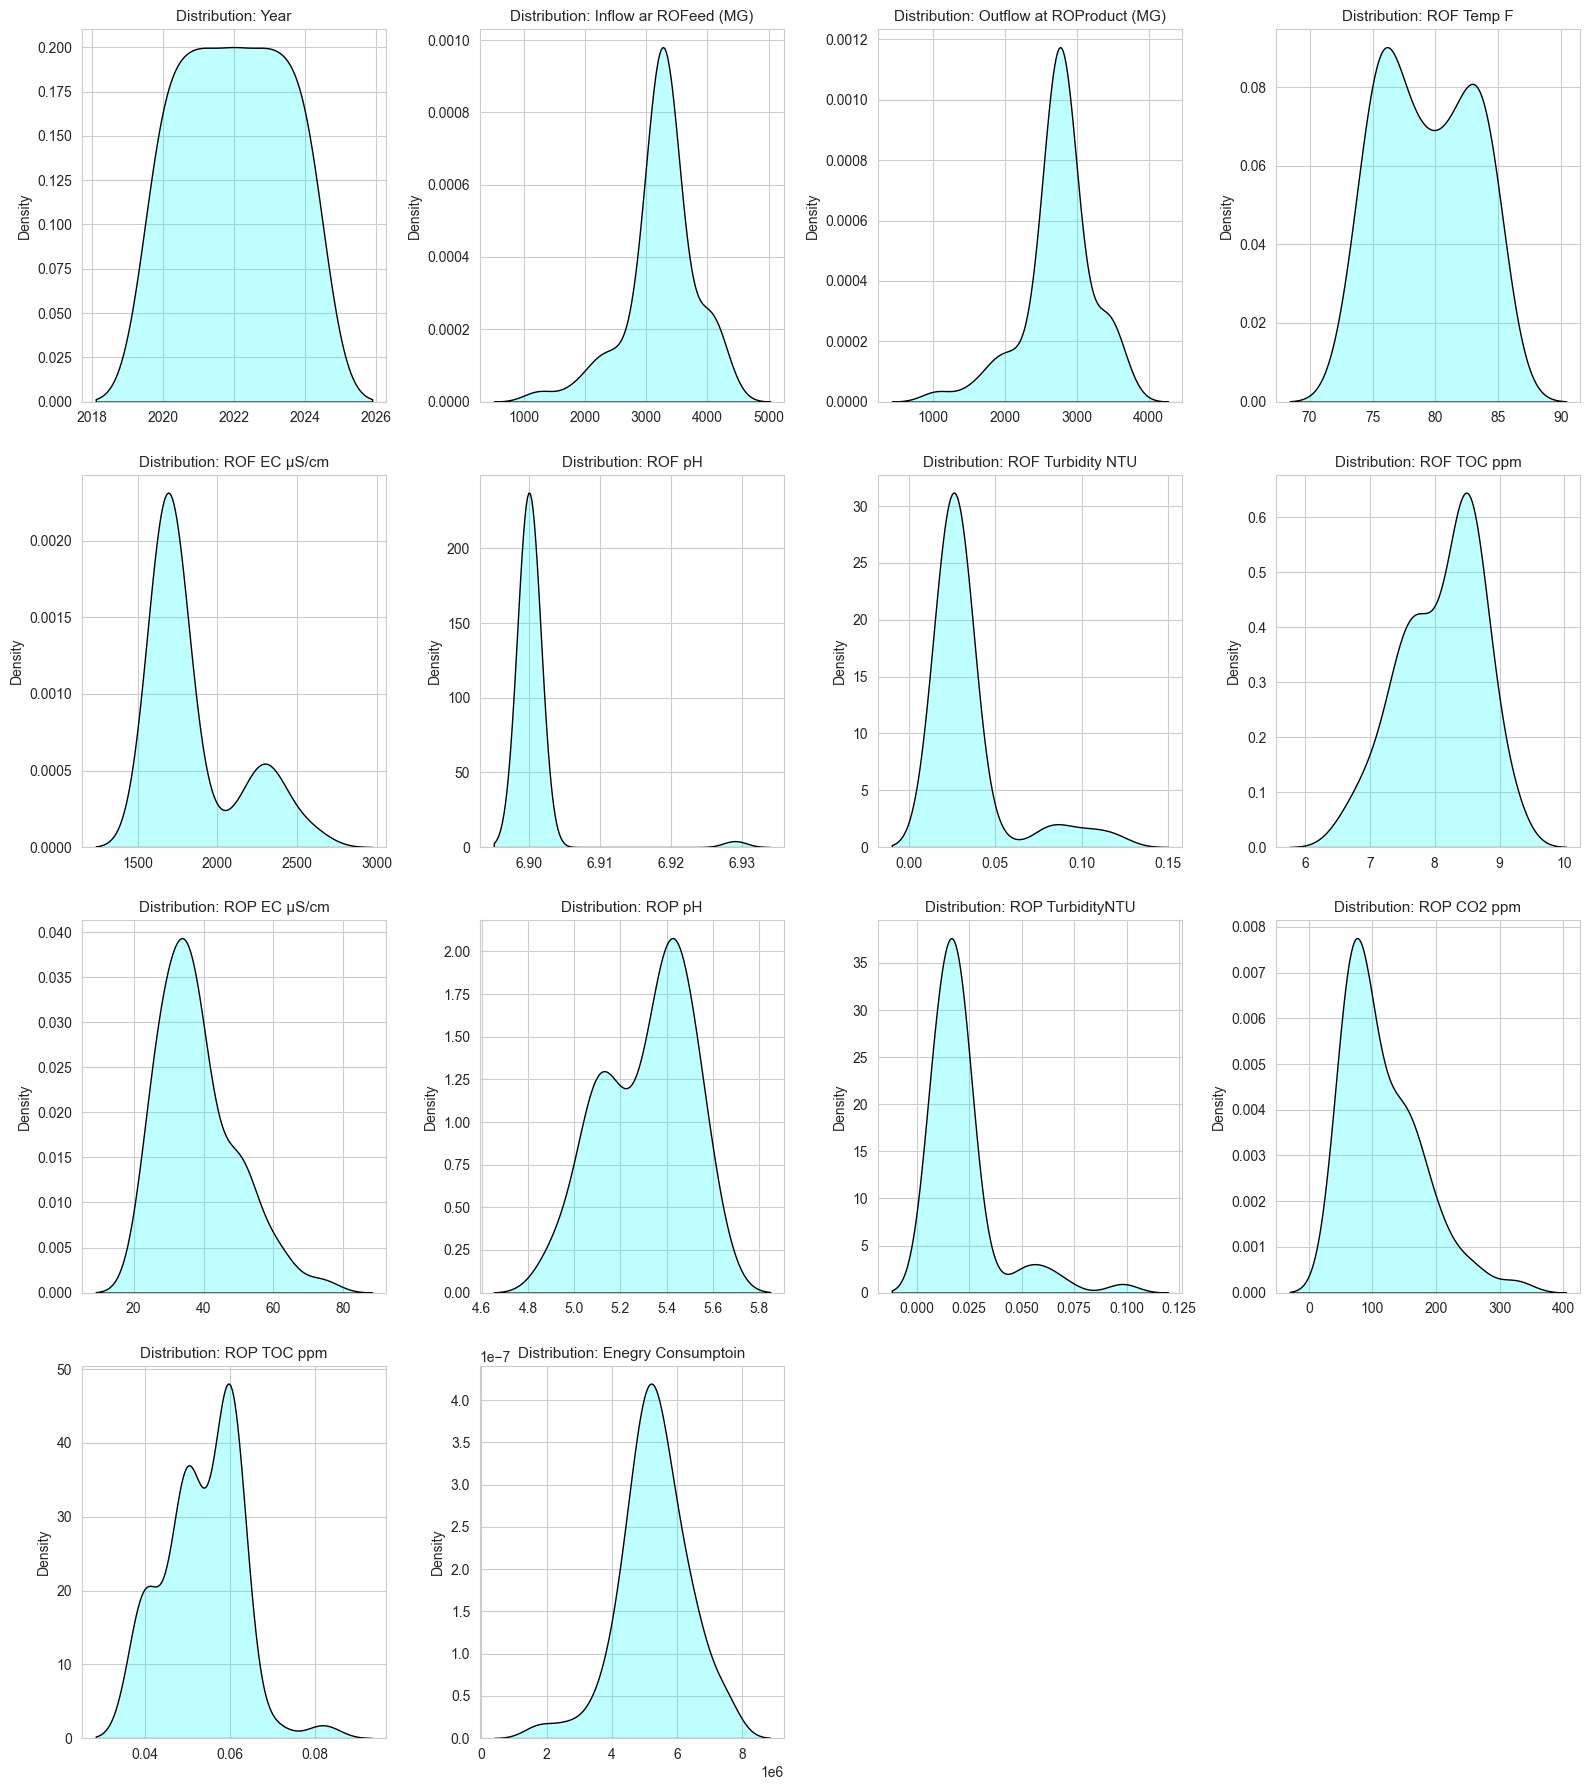

In [6]:
import math

numeric_df = df.select_dtypes(include='number')

# Layout settings
num_cols = 4
num_rows = math.ceil(len(numeric_df.columns) / num_cols)

plt.figure(figsize=(14, num_rows * 2.5))
sns.set_style("whitegrid")

# Plotting distributions
plt.figure(figsize=(16, 18))
for i, col in enumerate(numeric_df.columns, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.kdeplot(numeric_df, x=col, fill=True, color='cyan', edgecolor='black')
    plt.title(f'Distribution: {col}', fontsize=11)
    plt.xlabel('')
    plt.ylabel('Density')

plt.tight_layout()
plt.show();

In [8]:
df.head()

,Year,Month,Inflow ar ROFeed (MG),Outflow at ROProduct (MG),ROF Temp F,ROF EC µS/cm,ROF pH,ROF Turbidity NTU,ROF TOC ppm,ROP EC µS/cm,ROP pH,ROP TurbidityNTU,ROP CO2 ppm,ROP TOC ppm,Enegry Consumptoin,month_num
0,2024,Jan,4121.564,3509.815,75.19,2326.0,6.9,0.03,7.99,43.7,5.4,0.02,90.64,0.05,6794155.0,1
24,2022,Jan,3279.873,2784.005,75.07,1651.0,6.9,0.03,8.54,49.9,5.1,0.02,151.83,0.05,5022596.0,1
36,2021,Jan,3251.220,2759.594,75.07,1672.0,6.9,0.02,8.77,26.2,5.4,0.03,81.77,0.05,5433832.0,1
12,2023,Jan,4010.909,3390.159,73.85,2391.0,6.9,0.03,7.40,47.4,5.1,0.01,170.99,0.04,6583584.0,1
48,2020,Jan,3501.892,2978.597,75.21,1727.0,6.9,0.08,7.88,30.4,5.4,0.06,71.82,0.04,5877645.0,1


In [ ]:
df.drop('Enegry Consumptoin', axis=1, inplace=True)

## Random Forest Regressor

In [9]:
from sklearn.metrics import root_mean_squared_error


df.columns = [c.strip().replace('\n', ' ').replace('\\', '').replace('ْ', '') for c in df.columns]

month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

df['month_num'] = df['Month'].map(month_map)

# Select features and target
target = 'Enegry Consumptoin'
drop_cols = ['Year', 'Month', target]
X = df.drop(columns=drop_cols)
y = df[target]

# Feature Scaling (optional for tree models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Model setup
model = RandomForestRegressor(random_state=42, n_estimators=100)

# Leave-One-Out Cross Validation
loo = LeaveOneOut()
y_pred = cross_val_predict(model, X_scaled, y, cv=loo)

# Evaluation
rmse = root_mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"LOOCV RMSE: {rmse:.2f}")
print(f"LOOCV R² Score: {r2:.2f}")


LOOCV RMSE: 590907.24
LOOCV R² Score: 0.68


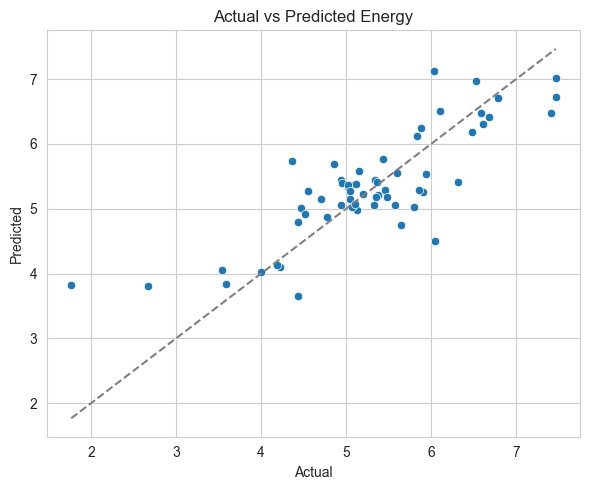

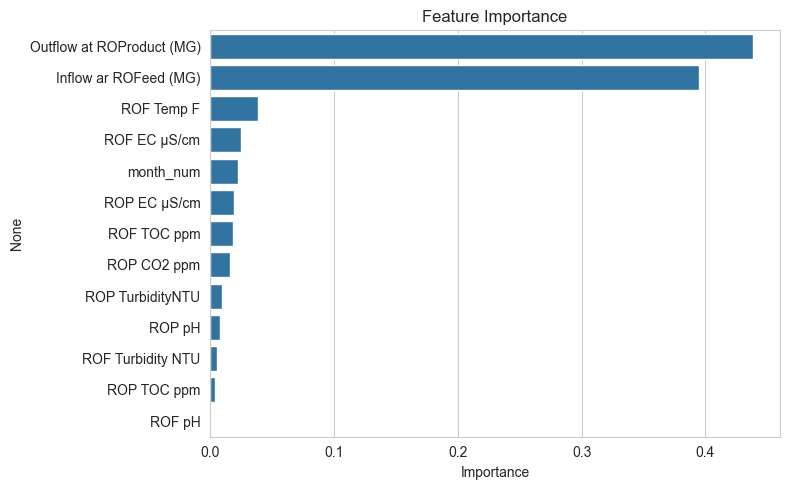

In [ ]:
# ---- Plot: Actual vs Predicted ----
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='gray')
plt.title("Actual vs Predicted Energy")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Feature Importance ----
model.fit(X_scaled, y)
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score


# Defining models
models = {
    'Linear Regression': LinearRegression(),
    'Support Vector Regression': SVR(kernel='rbf', C=10, epsilon=0.1),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Evaluating models
results = []
loo = LeaveOneOut()
for name, model in models.items():
    y_pred = cross_val_predict(model, X_scaled, y, cv=loo)
    rmse = root_mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

# Displaying results
results_df = pd.DataFrame(results)
print(results_df)


                       Model          RMSE        R2
0          Linear Regression  5.433887e+05  0.727163
1  Support Vector Regression  1.090304e+06 -0.098442
2    Random Forest Regressor  5.909072e+05  0.677359
3          XGBoost Regressor  6.088139e+05  0.657508


###  Model Evaluation Summary (LOOCV)

| Model                     | RMSE (kWh)    | R² Score |
|---------------------------|---------------|----------|
| **Linear Regression**     | **543,389**   | **0.73** |
| Random Forest Regressor   | 590,907       | 0.68     |
| XGBoost Regressor         | 608,814       | 0.66     |
| Support Vector Regression | 1,090,304     | -0.10    |

---

### ✅ Key Takeaways:

- **Linear Regression** provided the best performance with the lowest RMSE and highest R², making it the top choice for this dataset.
- **Random Forest** and **XGBoost** also performed well, capturing complex patterns and offering robustness with slightly higher error.
- **Support Vector Regression (SVR)** was not effective, yielding a negative R², indicating it is not suitable without significant tuning or preprocessing.



In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from itertools import product

model = RandomForestRegressor(random_state=42, n_estimators=100)
X = df.drop(columns=['Year', 'Month', 'Enegry Consumptoin'])
y = df['Enegry Consumptoin']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model.fit(X_scaled, y)

search_space = {
    'Inflow ar ROFeed (MG)': np.linspace(2500, 3500, 5),
    'Outflow at ROProduct (MG)': np.linspace(2100, 3100, 5),
    'ROF Temp F': np.linspace(70, 80, 3),
    'ROF EC µS/cm': np.linspace(1500, 2500, 3),
    'ROF pH': [6.8, 6.9, 7.0],
    'ROP pH': [5.1, 5.3, 5.5],
    'ROP EC µS/cm': [20, 30, 40]
}

keys = list(search_space.keys())
grid = list(product(*search_space.values()))

results = []
for values in grid:
    x_dict = dict(zip(keys, values))
    x_full = {col: np.mean(X[col]) for col in X.columns}  # baseline
    x_full.update(x_dict)  # override with custom inputs
    x_df = pd.DataFrame([x_full])
    x_scaled = scaler.transform(x_df)
    y_pred = model.predict(x_scaled)[0]
    results.append((x_dict, y_pred))

results_sorted = sorted(results, key=lambda x: x[1])
best_input, best_energy = results_sorted[0]

print("\n🔧 Optimal Settings to Minimize Energy:")
for k, v in best_input.items():
    print(f"{k}: {v}")
print(f"\n🔥 Predicted Energy: {best_energy:.0f} kWh")



🔧 Optimal Settings to Minimize Energy:
Inflow ar ROFeed (MG): 2500.0
Outflow at ROProduct (MG): 2100.0
ROF Temp F: 70.0
ROF EC µS/cm: 1500.0
ROF pH: 6.8
ROP pH: 5.5
ROP EC µS/cm: 20

🔥 Predicted Energy: 3822640 kWh


Optuna based

In [ ]:
pip install optuna

In [ ]:
import optuna
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Setup
target_col = 'Enegry Consumptoin'
X = df.drop(columns=['Year', 'Month', target_col])
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_scaled, y)

# Optuna optimization function
def objective(trial):
    x = {}
    for col in X.columns:
        col_min = X[col].min()
        col_max = X[col].max()
        x[col] = trial.suggest_float(col, col_min, col_max)
    x_df = pd.DataFrame([x])
    x_scaled = scaler.transform(x_df)
    return model.predict(x_scaled)[0]

# Run Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200)


[I 2025-04-12 19:14:08,340] A new study created in memory with name: no-name-24bbd8ae-d5d7-4be6-97ac-de8f9cc39b42
[I 2025-04-12 19:14:08,361] Trial 0 finished with value: 2788068.4 and parameters: {'Inflow ar ROFeed (MG)': 1383.7111026180914, 'Outflow at ROProduct (MG)': 1373.687117874596, 'ROF Temp F': 84.0984273689957, 'ROF EC µS/cm': 2012.3099092815823, 'ROF pH': 6.923563779778698, 'ROF Turbidity NTU': 0.07508587311890355, 'ROF TOC ppm': 7.071383748274016, 'ROP EC µS/cm': 60.74873936749203, 'ROP pH': 4.992939624880225, 'ROP TurbidityNTU': 0.02471683165785493, 'ROP CO2 ppm': 77.00234355882264, 'ROP TOC ppm': 0.049448496685381954}. Best is trial 0 with value: 2788068.4.
[I 2025-04-12 19:14:08,379] Trial 1 finished with value: 4629843.05 and parameters: {'Inflow ar ROFeed (MG)': 2311.1442295337947, 'Outflow at ROProduct (MG)': 2621.404858374094, 'ROF Temp F': 76.48364406685253, 'ROF EC µS/cm': 2383.5504948196112, 'ROF pH': 6.916625714308863, 'ROF Turbidity NTU': 0.10859319643074206, 'R

🔧 Best parameters:
Inflow ar ROFeed (MG): 1304.816
Outflow at ROProduct (MG): 1152.883
ROF Temp F: 85.202
ROF EC µS/cm: 1664.099
ROF pH: 6.922
ROF Turbidity NTU: 0.024
ROF TOC ppm: 9.155
ROP EC µS/cm: 48.113
ROP pH: 5.566
ROP TurbidityNTU: 0.093
ROP CO2 ppm: 60.757
ROP TOC ppm: 0.060

🔥 Predicted minimum energy: 2425996 kWh


In [31]:
# Results
print("🔧 Best parameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v:.3f}")
print(f"\n🔥 Predicted minimum energy: {study.best_value:.0f} kWh")


🔧 Best parameters:
Inflow ar ROFeed (MG): 1304.816
Outflow at ROProduct (MG): 1152.883
ROF Temp F: 85.202
ROF EC µS/cm: 1664.099
ROF pH: 6.922
ROF Turbidity NTU: 0.024
ROF TOC ppm: 9.155
ROP EC µS/cm: 48.113
ROP pH: 5.566
ROP TurbidityNTU: 0.093
ROP CO2 ppm: 60.757
ROP TOC ppm: 0.060

🔥 Predicted minimum energy: 2425996 kWh


## Genetic Algorithm

In [ ]:
pip install pygad

In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import pygad

target_col = 'Enegry Consumptoin'
X = df.drop(columns=['Year', 'Month', target_col])
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_scaled, y)

# --- Genetic Algorithm Setup ---
# Get bounds for each feature
bounds = [(X[col].min(), X[col].max()) for col in X.columns]

# --- Updated Fitness Function for PyGAD 2.20.0 ---
def fitness_func(ga_instance, solution, solution_idx):
    input_dict = dict(zip(X.columns, solution))
    input_df = pd.DataFrame([input_dict])
    input_scaled = scaler.transform(input_df)
    predicted_energy = model.predict(input_scaled)[0]
    return -predicted_energy  # minimize energy


# Define gene space
gene_space = [{'low': b[0], 'high': b[1]} for b in bounds]

# Create GA instance
ga_instance = pygad.GA(
    num_generations=100,
    num_parents_mating=5,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=len(X.columns),
    gene_space=gene_space,
    parent_selection_type="rank",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20,
    allow_duplicate_genes=False
)

# --- Run the GA ---
ga_instance.run()

# --- Extract Results ---
solution, solution_fitness, _ = ga_instance.best_solution()
optimal_values = dict(zip(X.columns, solution))
predicted_energy = -solution_fitness




In [35]:
# Output
print("\n🧬 Genetic Algorithm Optimal Inputs:")
for k, v in optimal_values.items():
    print(f"{k}: {v:.3f}")
print(f"\n🔥 Predicted Minimum Energy: {predicted_energy:.0f} kWh")


🧬 Genetic Algorithm Optimal Inputs:
Inflow ar ROFeed (MG): 1768.934
Outflow at ROProduct (MG): 1438.262
ROF Temp F: 84.363
ROF EC µS/cm: 1770.902
ROF pH: 6.922
ROF Turbidity NTU: 0.034
ROF TOC ppm: 8.345
ROP EC µS/cm: 34.073
ROP pH: 5.468
ROP TurbidityNTU: 0.053
ROP CO2 ppm: 85.963
ROP TOC ppm: 0.040

🔥 Predicted Minimum Energy: 3080664 kWh


**Reverse Osmosis (RO) Energy Optimization Report**

---

### 🌍 Project Overview
The primary objective of this study is to develop a machine learning-based framework to minimize energy consumption in a Reverse Osmosis (RO) water treatment plant. The system currently operates at a fixed set-point, which does not adapt to dynamic water quality and operational changes, leading to suboptimal energy efficiency.

This report outlines the modeling approach, insights derived from the data, and optimization results using three techniques:
- Grid Search (Brute-force simulation)
- Bayesian Optimization (Optuna)
- Genetic Algorithm (PyGAD)

---

### 📊 Modeling Summary

- **Dataset**: Monthly operational and water quality data (2024)
- **Target Variable**: Monthly energy consumption (kWh)
- **Model**: Random Forest Regressor
- **Validation**: Leave-One-Out Cross-Validation (LOOCV)

**Performance Metrics:**
- **RMSE**: 0.59 million kWh
- **R² Score**: 0.67

The model demonstrates strong predictive ability despite the limited sample size, capturing 67% of the variance in energy usage.

---

### 🎯 Feature Importance
Key drivers of energy consumption:
1. **Outflow at ROProduct (MG)**
2. **Inflow ar ROFeed (MG)**
3. **ROF Temp** and **ROF EC** (moderate)
4. **ROP EC**, **ROP pH**, **TOC** values (low-moderate)

These results highlight that **flow volume** is the most critical factor, with water quality variables playing secondary roles.

---

### 🔄 Optimization Results

#### ✉️ Grid Search (Brute-force)
- **Inflow**: 2500.0 MG
- **Outflow**: 2100.0 MG
- **Temp**: 70.0 F
- **ROF EC**: 1500.0 µS/cm
- **ROF pH**: 6.8
- **ROP pH**: 5.5
- **ROP EC**: 20 µS/cm
- ✨ **Predicted Energy**: **3,822,640 kWh**

#### 🌿 Optuna (Bayesian Optimization)
- **Inflow**: 1304.82 MG
- **Outflow**: 1152.88 MG
- **Temp**: 85.20 F
- **ROF EC**: 1664.10 µS/cm
- **ROF pH**: 6.922
- **ROF Turbidity**: 0.024 NTU
- **ROF TOC**: 9.155 ppm
- **ROP EC**: 48.113 µS/cm
- **ROP pH**: 5.566
- **ROP Turbidity**: 0.093 NTU
- **ROP CO2**: 60.76 ppm
- **ROP TOC**: 0.060 ppm
- ✨ **Predicted Energy**: **2,425,996 kWh** (Lowest)

#### 🦜 Genetic Algorithm (PyGAD)
- **Inflow**: 1768.93 MG
- **Outflow**: 1438.26 MG
- **Temp**: 84.36 F
- **ROF EC**: 1770.90 µS/cm
- **ROF pH**: 6.922
- **ROF Turbidity**: 0.034 NTU
- **ROF TOC**: 8.345 ppm
- **ROP EC**: 34.073 µS/cm
- **ROP pH**: 5.468
- **ROP Turbidity**: 0.053 NTU
- **ROP CO2**: 85.96 ppm
- **ROP TOC**: 0.040 ppm
- ✨ **Predicted Energy**: **3,080,664 kWh**

---

### 💡 Key Insights & Recommendations
- **Optuna** discovered the most energy-efficient operational window, but some parameter ranges may be aggressive and require feasibility review.
- **Genetic Algorithm** provided a strong balance between optimization and operational realism.
- **Grid Search** gives the most interpretable and manually controllable setup.
